#US bysykkel data

- data is from 2024
- Contact person is Christoffer Bakken Åkre (US)

## Load data fron raw_files

In [54]:
import pandas as pd
from pathlib import Path
import os

In [55]:
# Get the directory where this notebook is located
notebook_dir = Path(os.getcwd())

# Create relative path to raw_files
raw_files_dir = notebook_dir / 'trip_data' / 'raw_files'

# Load all parquet files
parquet_files = sorted(raw_files_dir.glob('*.parquet'))

print(f"Found {len(parquet_files)} parquet files in {raw_files_dir}")

# Load all files into a list of dataframes
dfs = []
for file in parquet_files:
    print(f"Loading {file.name}...")
    df = pd.read_parquet(file)
    dfs.append(df)

# Combine all dataframes
data = pd.concat(dfs, ignore_index=True)

data.head()

Found 9 parquet files in c:\Users\ingvivsu\FOMOsim\policies\sjovik_sund\US_data\trip_data\raw_files
Loading 000000000000.parquet...
Loading 000000000001.parquet...
Loading 000000000002.parquet...
Loading 000000000003.parquet...
Loading 000000000004.parquet...
Loading 000000000005.parquet...
Loading 000000000006.parquet...
Loading 000000000007.parquet...
Loading 000000000008.parquet...


,vehicle_id,position_at,position_wkt,position_latitude,position_longitude,position_accuracy,trip_started_at,trip_ended_at,trip_id,trip_state,...,trip_end_dock_number,trip_end_dock_group_id,trip_end_dock_group_title,user_id,product_id,product_name,product_price,product_sales_channel,product_sales_locale,sale_from_value_code
0,4036,2024-03-22 05:51:00.756,b'\x01\x01\x00\x00\x00\xe0-\x90\xa0\xf8\xd1$@\...,63.4356,10.4101,719,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
1,4036,2024-03-22 05:51:16.061,b'\x01\x01\x00\x00\x00\xe0-\x90\xa0\xf8\xd1$@\...,63.4356,10.4101,553,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
2,4036,2024-03-22 05:51:30.793,b'\x01\x01\x00\x00\x00\xe4\x83\x9e\xcd\xaa\xcf...,63.4352,10.4056,79,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
3,4036,2024-03-22 05:51:45.773,b'\x01\x01\x00\x00\x00;\x01M\x84\r\xcf$@:\xb4\...,63.4355,10.4044,79,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
4,4036,2024-03-22 05:51:53.128,b'\x01\x01\x00\x00\x00\xe6?\xa4\xdf\xbe\xce$@\...,63.4357,10.4038,74,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False


In [56]:
# Check for duplicates in the loaded data
print(f"Total rows: {len(data)}")
print(f"Unique rows: {data.drop_duplicates().shape[0]}")
print(f"\nData shape: {data.shape}")
print(f"\nData info:")
data.info()

Total rows: 5748944
Unique rows: 5747513

Data shape: (5748944, 24)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5748944 entries, 0 to 5748943
Data columns (total 24 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   vehicle_id                   int64         
 1   position_at                  datetime64[us]
 2   position_wkt                 object        
 3   position_latitude            float64       
 4   position_longitude           float64       
 5   position_accuracy            int64         
 6   trip_started_at              datetime64[us]
 7   trip_ended_at                datetime64[us]
 8   trip_id                      int64         
 9   trip_state                   object        
 10  trip_unlock_method           object        
 11  trip_start_dock_number       int64         
 12  trip_start_dock_group_id     int64         
 13  trip_start_dock_group_title  object        
 14  trip_end_dock_numb

## Data Dictionary

Description of fields in the US bysykkel dataset:

In [57]:
# Create a data dictionary by examining the data
field_descriptions = {
    'vehicle_id': 'Unique identifier for the bike/scooter',
    'position_at': 'Timestamp of the position reading',
    'position_wkt': 'Well-Known Text representation of position',
    'position_latitude': 'Latitude coordinate of the vehicle',
    'position_longitude': 'Longitude coordinate of the vehicle',
    'position_accuracy': 'GPS accuracy of the position reading',
    'trip_started_at': 'Timestamp when the trip started',
    'trip_ended_at': 'Timestamp when the trip ended',
    'trip_id': 'Unique identifier for the trip',
    'trip_state': 'Current state of the trip (e.g., active, completed)',
    'trip_unlock_method': 'Method used to unlock the vehicle',
    'trip_start_dock_number': 'Dock number where trip started',
    'trip_start_dock_group_id': 'ID of the dock group/station where trip started',
    'trip_start_dock_group_title': 'Name of the dock group/station where trip started',
    'trip_end_dock_number': 'Dock number where trip ended',
    'trip_end_dock_group_id': 'ID of the dock group/station where trip ended',
    'trip_end_dock_group_title': 'Name of the dock group/station where trip ended',
    'user_id': 'Unique identifier for the user',
    'product_id': 'ID of the product/subscription type',
    'product_name': 'Name of the product/subscription type',
    'product_price': 'Price of the product',
    'product_sales_channel': 'Channel through which the product was sold',
    'product_sales_locale': 'Locale/language of the sale',
    'sale_from_value_code': 'Code indicating the source/type of sale'
}

# Display as a formatted table
import pandas as pd
field_df = pd.DataFrame([
    {'Field': field, 'Description': desc, 'Type': str(data[field].dtype), 
     'Non-Null': data[field].notna().sum(), 'Null': data[field].isna().sum()}
    for field, desc in field_descriptions.items()
])

print("Data Dictionary:")
print("="*100)
field_df

Data Dictionary:


,Field,Description,Type,Non-Null,Null
0,vehicle_id,Unique identifier for the bike/scooter,int64,5748944,0
1,position_at,Timestamp of the position reading,datetime64[us],5748944,0
2,position_wkt,Well-Known Text representation of position,object,5748944,0
3,position_latitude,Latitude coordinate of the vehicle,float64,5748944,0
4,position_longitude,Longitude coordinate of the vehicle,float64,5748944,0
5,position_accuracy,GPS accuracy of the position reading,int64,5748944,0
6,trip_started_at,Timestamp when the trip started,datetime64[us],5748944,0
7,trip_ended_at,Timestamp when the trip ended,datetime64[us],5748944,0
8,trip_id,Unique identifier for the trip,int64,5748944,0
9,trip_state,"Current state of the trip (e.g., active, compl...",object,5748944,0


## Full data profile to txt

In [58]:
# 1. Define the output file
output_file = "full_data_profile.txt"

# 2. Capture all columns in the dataframe
all_fields = data.columns.tolist()

# Using utf-8 encoding to ensure all special characters are captured correctly
with open(output_file, "w", encoding='utf-8') as f:
    f.write("--- COMPLETE DATA PROFILE ---\n")
    f.write(f"Total Columns Processed: {len(all_fields)}\n")
    f.write("="*40 + "\n")

    for field in all_fields:
        f.write(f"\nCOLUMN: {field}\n")
        f.write(f"  Total Unique Values: {data[field].nunique()}\n")
        f.write(f"  All Unique Values & Counts:\n")
        
        # value_counts() defaults to descending order, showing most frequent first
        counts = data[field].value_counts()
        
        # We iterate directly over the Series items
        for val, count in counts.items():
            f.write(f"    - {val}: {count}\n")
        
        f.write("-" * 30 + "\n")

print(f"Done! All unique values for every field have been printed to {output_file}")

Done! All unique values for every field have been printed to full_data_profile.txt


# Trip pattern analysis


## Length of trip

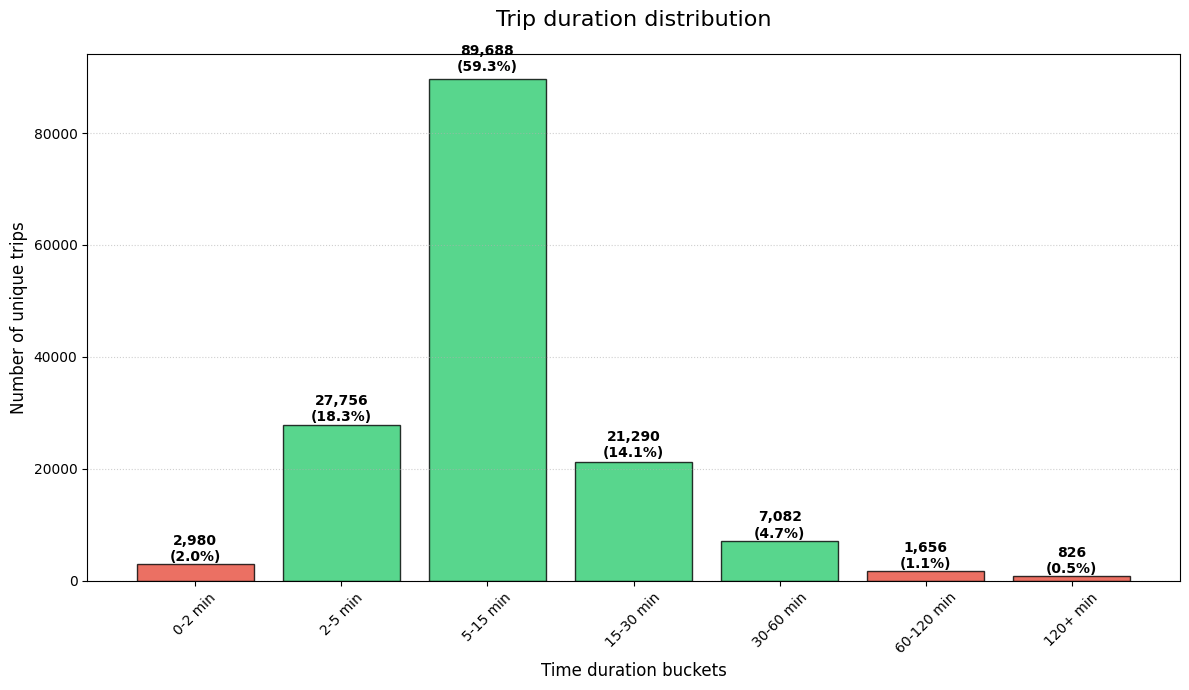

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Processing (Calculate unique trips and durations)
unique_trips = data.groupby('trip_id').first().reset_index()
trip_durations = (pd.to_datetime(unique_trips['trip_ended_at']) - 
                  pd.to_datetime(unique_trips['trip_started_at'])).dt.total_seconds() / 60

# 2. Define Granular Bins
bins = [0, 2, 5, 15, 30, 60, 120, float('inf')]
labels = ['0-2 min', '2-5 min', '5-15 min', '15-30 min', '30-60 min', '60-120 min', '120+ min']

# Cut data into buckets
duration_buckets = pd.cut(trip_durations, bins=bins, labels=labels)
counts = duration_buckets.value_counts().reindex(labels)

# 3. Define Color Logic
# Leftmost (index 0) and two rightmost (last two indices) = Red
# Everything else = Green
colors = []
for i in range(len(labels)):
    if i == 0 or i >= (len(labels) - 2):
        colors.append('#e74c3c') # Soft Red
    else:
        colors.append('#2ecc71') # Soft Green

# 4. Create the Visualization
plt.figure(figsize=(12, 7))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.8)

# Formatting
plt.title('Trip duration distribution', fontsize=16, pad=20)
plt.xlabel('Time duration buckets', fontsize=12)
plt.ylabel('Number of unique trips', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Add Data Labels (Counts and Percentages)
total_trips = len(trip_durations)
for bar in bars:
    height = bar.get_height()
    if not np.isnan(height):
        percentage = (height / total_trips) * 100
        plt.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01),
                 f'{int(height):,}\n({percentage:.1f}%)', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

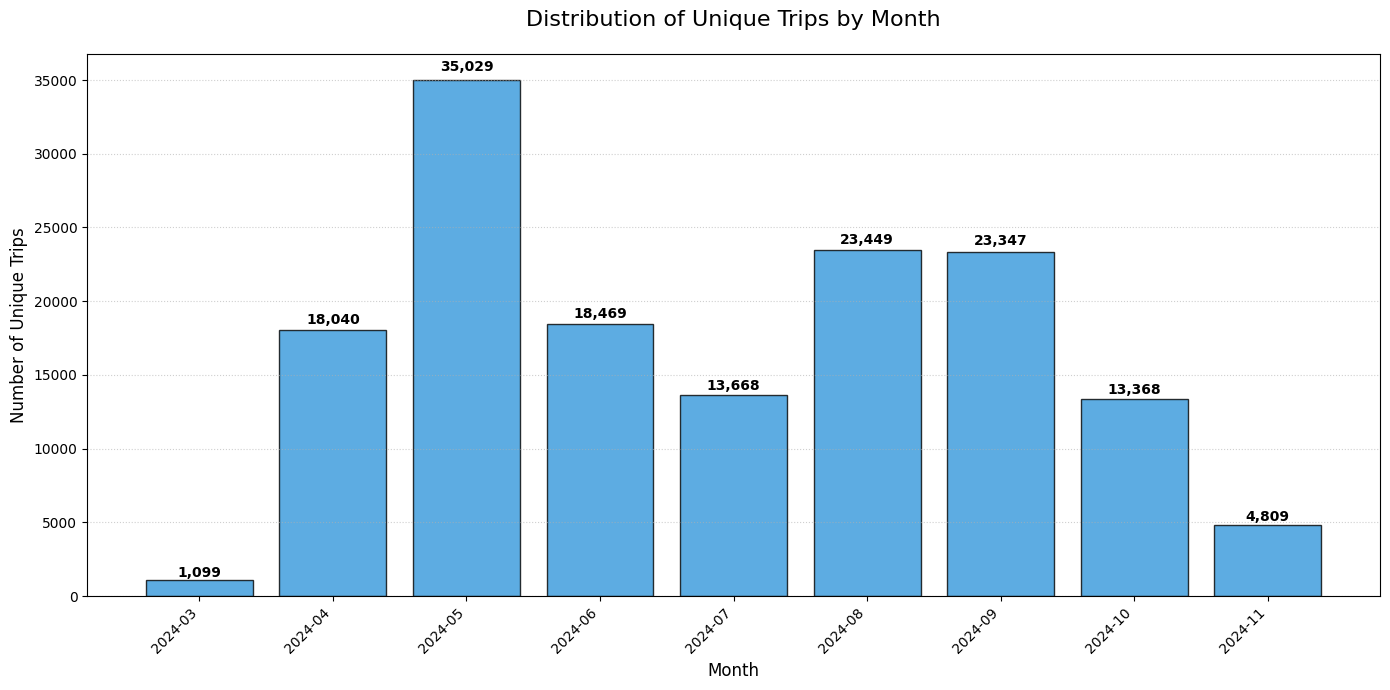


Monthly Trip Statistics:
Total months in dataset: 9
Average trips per month: 16,809
Minimum trips (month): 1,099 (2024-03)
Maximum trips (month): 35,029 (2024-05)


In [60]:
# Distribution of unique trips by month
import matplotlib.pyplot as plt

# Convert trip_started_at to datetime and extract year-month
unique_trips['trip_started_at'] = pd.to_datetime(unique_trips['trip_started_at'])
unique_trips['year_month'] = unique_trips['trip_started_at'].dt.to_period('M')

# Count unique trips per month
trips_by_month = unique_trips.groupby('year_month')['trip_id'].count().reset_index()
trips_by_month.columns = ['month', 'trip_count']
trips_by_month['month'] = trips_by_month['month'].astype(str)

# Create the visualization
plt.figure(figsize=(14, 7))
bars = plt.bar(trips_by_month['month'], trips_by_month['trip_count'], 
               color='#3498db', edgecolor='black', alpha=0.8)

# Formatting
plt.title('Distribution of Unique Trips by Month', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Unique Trips', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Add data labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01),
             f'{int(height):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nMonthly Trip Statistics:")
print(f"Total months in dataset: {len(trips_by_month)}")
print(f"Average trips per month: {trips_by_month['trip_count'].mean():,.0f}")
print(f"Minimum trips (month): {trips_by_month['trip_count'].min():,} ({trips_by_month.loc[trips_by_month['trip_count'].idxmin(), 'month']})")
print(f"Maximum trips (month): {trips_by_month['trip_count'].max():,} ({trips_by_month.loc[trips_by_month['trip_count'].idxmax(), 'month']})")

In [61]:
# Show unique long trips (over 90 minutes)
unique_trips['trip_duration_minutes'] = trip_durations
long_trips = unique_trips[trip_durations > 90][['trip_id', 'trip_start_dock_group_title',
                                                 'trip_end_dock_group_title','trip_started_at', 
                                                 'trip_ended_at', 'trip_duration_minutes']]

print(f"\nLong trips (over 90 minutes): {len(long_trips)} unique trips")
print("="*100)
long_trips.head(30)


Long trips (over 90 minutes): 1301 unique trips


,trip_id,trip_start_dock_group_title,trip_end_dock_group_title,trip_started_at,trip_ended_at,trip_duration_minutes
82,60473464,Trondheim S,None,2024-03-23 08:21:32.963,2024-03-23 11:35:00.436,193.457883
108,60476841,Strandveikaia,Lade idrettsanlegg vest,2024-03-23 12:46:11.145,2024-03-23 14:40:29.853,114.311800
164,60480481,TMV-odden,Lilleby,2024-03-23 18:03:14.493,2024-03-23 20:17:00.990,133.774950
201,60484696,Strandveikaia,None,2024-03-24 10:07:06.287,2024-03-24 13:10:01.042,182.912583
216,60487257,Dokkparken,None,2024-03-24 12:53:17.244,2024-03-24 15:55:01.085,181.730683
550,60522250,Nordre gate,None,2024-03-27 07:40:57.513,2024-03-27 10:45:00.456,184.049050
585,60525208,Kong Øysteins veg,Kong Øysteins veg,2024-03-27 12:52:51.634,2024-03-27 14:38:31.659,105.667083
705,60539554,Nordre gate,Dalen hageby,2024-03-28 14:29:22.868,2024-03-28 16:30:47.439,121.409517
721,60541328,Studentersamfundet,Studentersamfundet,2024-03-28 16:28:48.949,2024-03-28 18:08:52.301,100.055867
771,60547711,TMV-odden,TMV-odden,2024-03-29 10:23:25.751,2024-03-29 13:03:18.620,159.881150


# station analysis

In [62]:
# show unique stations, which are displayed in the data as trip_start_dock_group_title and trip_end_dock_group_title

unique_start_stations = data['trip_start_dock_group_title'].unique()
unique_end_stations = data['trip_end_dock_group_title'].unique()

print(f"Unique start stations: {len(unique_start_stations)}")
print(f"Unique end stations: {len(unique_end_stations)}")

# print all unique start stations
print("\nUnique Start Stations:")
for station in unique_start_stations:
    print(f"- {station}")

# print all end stations that are not included in start stations
print("\n")
print("\nUnique End Stations (not in start stations):")
for station in unique_end_stations:
    if station not in unique_start_stations:
        print(f"- {station}")

Unique start stations: 70
Unique end stations: 73

Unique Start Stations:
- TMV-odden
- Skansen
- Jomfrugateallmenningen
- Torvet II
- Nordre gate 
- Studentersamfundet
- Trondheim S
- Klostergata
- Verftsbrua
- Erling Skakkes gate
- St. Olavs gate
- Ilsvika
- Leutenhaven
- Lade Idrettsanlegg øst
- Kalvskinnet
- Bassengbakken
- Kongens gate
- Dokkparken
- Nova Kino
- Bakke bru
- Idrettsbygget Gløshaugen
- Ilevollen
- Møllenberg
- Lilleby
- Rosenborg skole
- Bakklandet
- Ilabekken
- Strandveikaia
- Thornesparken 
- Pirbadet
- Abels gate
- Trikkestallen på Lademoen
- Falkenborg
- Prinsen kinosenter
- Vollabakken
- Lade idrettsanlegg vest
- Lillegårdsbakken
- Håkon VIIs gate 8-10
- Tempe
- Hesthagen
- St. Olavs Hospital
- Finalebanen
- Sluppen
- Sorgenfri
- Singsaker
- Brattørkaia
- Dalen hageby
- Lerkendal
- Fjordgata
- Høyskoleringen
- Rosendal
- Torvet I
- Baldershage
- Kristiansten
- Gløshaugen
- Dora I
- Nidarø
- Kong Øysteins veg
- Berg Studentby
- Tollboden 
- S. P. Andersens vei
-

In [63]:
# make a dictionary that stores all start stations and a sorted list of the unique dock_numbers associated with that station. 

station_dock_dict = {}
for station in unique_start_stations:
    dock_numbers = data[data['trip_start_dock_group_title'] == station]['trip_start_dock_number'].unique()
    station_dock_dict[station] = sorted(dock_numbers)

# print the dictionary in a readable format. Include the length of the dock list.
print("\nStation to Dock Mapping:")
for station, docks in station_dock_dict.items():
    print(f"- {station} (Docks: {len(docks)})")
    docklist = []
    for dock in docks:
        docklist.append(int(dock))
    print(docklist)


Station to Dock Mapping:
- TMV-odden (Docks: 31)
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
- Skansen (Docks: 22)
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
- Jomfrugateallmenningen (Docks: 30)
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
- Torvet II (Docks: 20)
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
- Nordre gate  (Docks: 37)
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
- Studentersamfundet (Docks: 31)
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
- Trondheim S (Docks: 37)
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
- Klo

In [64]:
# make a dictionary that stores all unique end stations (that are not also start stations) and a sorted list of the unique dock_numbers associated with that station. 

only_end_stations = []

for station in unique_end_stations:
    if station not in unique_start_stations:
        only_end_stations.append(station)

station_end_dock_dict = {}
for station in only_end_stations:
    dock_numbers = data[data['trip_end_dock_group_title'] == station]['trip_end_dock_number'].unique()
    station_end_dock_dict[station] = sorted(dock_numbers)

# print the dictionary in a readable format. Include the length of the dock list.
print("\nStation to Dock Mapping:")
for station, docks in station_end_dock_dict.items():
    print(f"- {station} (Docks: {len(docks)})")
    docklist = []
    for dock in docks:
        docklist.append(int(dock))
    print(docklist)


Station to Dock Mapping:
- None (Docks: 0)
[]
- Voll Studentby (Docks: 1)
[1]
- Øvre Nyhavna/Virituell (Docks: 1)
[1]


In [65]:
# print the number of unique trips that are recorded for the only_end_stations by counting the number of unique trip_ids that have a trip_end_dock_group_title that matches each station in only_end_stations.

for station in only_end_stations:
    unique_trips_for_station = data[data['trip_end_dock_group_title'] == station]['trip_id'].nunique()
    print(f"{station}: {unique_trips_for_station} unique trips")

# print the number of rows the stations in only_end_stations occur in the dataset

for station in only_end_stations:
    rows_for_station = data[data['trip_end_dock_group_title'] == station].shape[0]
    print(f"{station}: {rows_for_station} rows in dataset")


for station in only_end_stations:
    unique_trips_for_station = data[data['trip_end_dock_group_title'] == station]['trip_id'].unique()
    print(f"{station}: {unique_trips_for_station} unique trips")



None: 0 unique trips
Voll Studentby: 1 unique trips
Øvre Nyhavna/Virituell: 1 unique trips
None: 0 rows in dataset
Voll Studentby: 2 rows in dataset
Øvre Nyhavna/Virituell: 18 rows in dataset
None: [] unique trips
Voll Studentby: [60492441] unique trips
Øvre Nyhavna/Virituell: [65410447] unique trips


In [66]:
# Get the first recorded position for each trip (should be at the start station)
# Sort by trip_id and position_at to ensure chronological order
data_sorted = data.sort_values(['trip_id', 'position_at'])

# Get the first position record for each trip
first_positions = data_sorted.groupby('trip_id').first().reset_index()

# Now aggregate by start station using these first positions
station_coords = first_positions.groupby('trip_start_dock_group_title').agg({
    'position_latitude': 'median',  # Use median to reduce outlier impact
    'position_longitude': 'median'
}).reset_index()

# Rename columns for clarity
station_coords.columns = ['station_name', 'latitude', 'longitude']

# Display the results
print(f"Total stations with coordinates: {len(station_coords)}")
print(f"Based on first positions from {len(first_positions)} trips")
print("\nStation Coordinates:")
station_coords

Total stations with coordinates: 70
Based on first positions from 151278 trips

Station Coordinates:


,station_name,latitude,longitude
0,Abels gate,63.4163,10.3962
1,Bakke bru,63.4321,10.4073
2,Bakklandet,63.4278,10.4033
3,Baldershage,63.4303,10.4540
4,Bassengbakken,63.4359,10.4147
...,...,...,...
65,Valentinlyst,63.4255,10.4412
66,Verftsbrua,63.4352,10.4059
67,Virtuell stasjon Olavsfest 24,63.4255,10.3940
68,Vollabakken,63.4219,10.3992


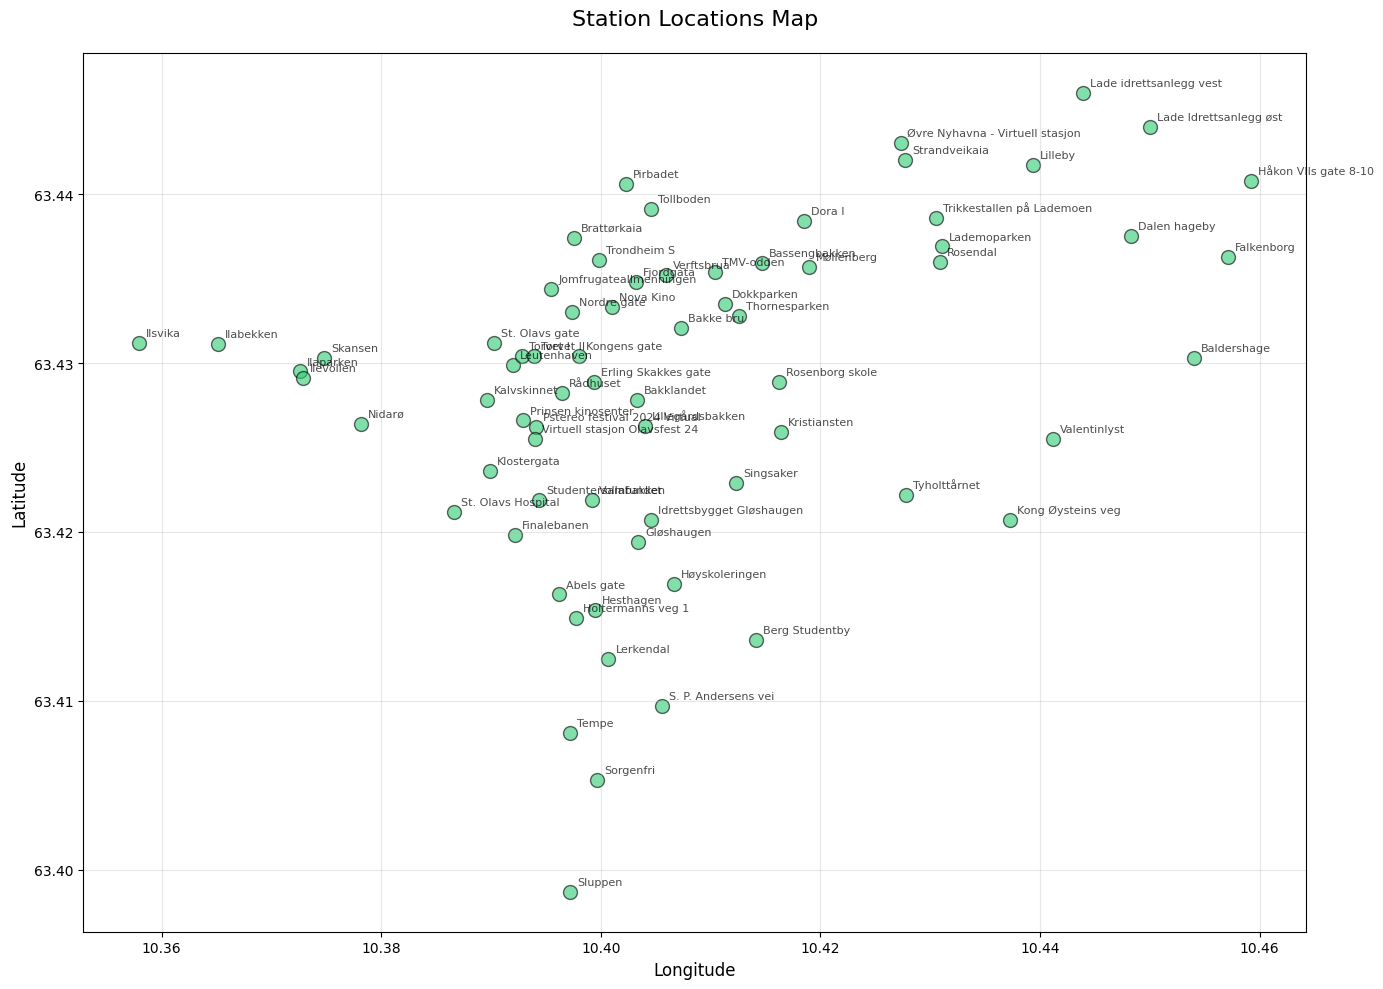


Coordinate ranges:
Latitude: 63.398700 to 63.446000
Longitude: 10.357900 to 10.459200


In [67]:
# Create a simple scatter plot map of stations
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
plt.scatter(station_coords['longitude'], station_coords['latitude'], 
            s=100, alpha=0.6, c='#2ecc71', edgecolors='black', linewidth=1)

# Add station names as labels
for idx, row in station_coords.iterrows():
    plt.annotate(row['station_name'], 
                (row['longitude'], row['latitude']),
                fontsize=8, 
                alpha=0.7,
                xytext=(5, 5), 
                textcoords='offset points')

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('Station Locations Map', fontsize=16, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCoordinate ranges:")
print(f"Latitude: {station_coords['latitude'].min():.6f} to {station_coords['latitude'].max():.6f}")
print(f"Longitude: {station_coords['longitude'].min():.6f} to {station_coords['longitude'].max():.6f}")

In [68]:
# Create an interactive map using folium
import folium

# Calculate center of the map (average of all station coordinates)
center_lat = station_coords['latitude'].mean()
center_lon = station_coords['longitude'].mean()

# Create the map
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

# Add markers for each station
for idx, row in station_coords.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=row['station_name'],
        tooltip=row['station_name'],
        icon=folium.Icon(color='green', icon='bicycle', prefix='fa')
    ).add_to(m)

# Display the map
m

# Extract full trips only

In [69]:
trip_data = data.copy()
def add_trip_distances(df):
    """
    Adds 'segment_distance_m' (distance from previous point)
    and 'total_trip_distance_meters' (total length of the trip)
    to the original dataframe.
    """
   
    # 1. Sort Data (Crucial for correct sequential calculation)
    # We sort in place or reassign to ensure the order is correct for shifting
    df = df.sort_values(by=['trip_id', 'position_at']).copy()
 
    # 2. Vectorized Haversine Calculation setup
    # Shift to get the "previous" point's coordinates per trip
    df['prev_lat'] = df.groupby('trip_id')['position_latitude'].shift(1)
    df['prev_lon'] = df.groupby('trip_id')['position_longitude'].shift(1)
 
    # 3. Calculate Distance for every row (Segment Distance)
    R = 6371000  # Earth radius in meters
   
    # We use numpy where to handle the first row of each trip (where prev is NaN)
    # This avoids dropping rows.
    lat1 = np.radians(df['prev_lat'])
    lon1 = np.radians(df['prev_lon'])
    lat2 = np.radians(df['position_latitude'])
    lon2 = np.radians(df['position_longitude'])
   
    dlat = lat2 - lat1
    dlon = lon2 - lon1
 
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
   
    # Calculate distance, filling NaNs (start of trips) with 0
    df['segment_distance_m'] = (R * c).fillna(0)
 
    # 4. Calculate Total Trip Distance (The new column you want)
    df['total_trip_distance_meters'] = df.groupby('trip_id')['segment_distance_m'].transform('sum')
   
    # Optional: Clean up helper columns if you don't want them cluttering the df
    df.drop(columns=['prev_lat', 'prev_lon'], inplace=True)
 
    return df
 
# --- Usage ---
trip_data = add_trip_distances(trip_data)
 
# Now trip_data has all original columns + 'segment_distance_m' + 'total_trip_distance_meters'
# print(trip_data[['trip_id', 'total_trip_distance_meters']].head())
 

In [70]:
# Group trips by trip_id and get the last row of each trip to have one row per trip with total distance
trip_data = trip_data.groupby('trip_id').last().reset_index()
trip_data = trip_data.drop(columns=['position_latitude', 'position_longitude', 'position_at'])
 
 

# Load maintenance data

In [71]:
trip_data_2024 = data

trip_data_2024.head()

,vehicle_id,position_at,position_wkt,position_latitude,position_longitude,position_accuracy,trip_started_at,trip_ended_at,trip_id,trip_state,...,trip_end_dock_number,trip_end_dock_group_id,trip_end_dock_group_title,user_id,product_id,product_name,product_price,product_sales_channel,product_sales_locale,sale_from_value_code
0,4036,2024-03-22 05:51:00.756,b'\x01\x01\x00\x00\x00\xe0-\x90\xa0\xf8\xd1$@\...,63.4356,10.4101,719,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
1,4036,2024-03-22 05:51:16.061,b'\x01\x01\x00\x00\x00\xe0-\x90\xa0\xf8\xd1$@\...,63.4356,10.4101,553,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
2,4036,2024-03-22 05:51:30.793,b'\x01\x01\x00\x00\x00\xe4\x83\x9e\xcd\xaa\xcf...,63.4352,10.4056,79,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
3,4036,2024-03-22 05:51:45.773,b'\x01\x01\x00\x00\x00;\x01M\x84\r\xcf$@:\xb4\...,63.4355,10.4044,79,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
4,4036,2024-03-22 05:51:53.128,b'\x01\x01\x00\x00\x00\xe6?\xa4\xdf\xbe\xce$@\...,63.4357,10.4038,74,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False


In [72]:
# Load CSV files from damage_data folder

notebook_dir = Path(os.getcwd())
damage_data_dir = notebook_dir / 'damage_data'

print(f"Loading CSV files from {damage_data_dir}\n")

# Load the three expected CSV files directly
asset_damage = pd.read_csv(damage_data_dir / 'asset_damage.csv')
print(f"Loaded 'asset_damage.csv' with shape {asset_damage.shape}")
print(type(asset_damage))

asset_maintenance = pd.read_csv(damage_data_dir / 'asset_maintenance.csv')
print(f"Loaded 'asset_maintenance.csv' with shape {asset_maintenance.shape}")

asset_repair = pd.read_csv(damage_data_dir / 'asset_repair.csv')
print(f"Loaded 'asset_repair.csv' with shape {asset_repair.shape}")

print("\n✅ All maintenance data loaded successfully!")

Loading CSV files from c:\Users\ingvivsu\FOMOsim\policies\sjovik_sund\US_data\damage_data

Loaded 'asset_damage.csv' with shape (756565, 16)
<class 'pandas.core.frame.DataFrame'>
Loaded 'asset_maintenance.csv' with shape (363324, 10)
Loaded 'asset_repair.csv' with shape (250815, 16)

✅ All maintenance data loaded successfully!


In [73]:
# Display basic info for each loaded dataframe
print("=" * 80)
print("DATAFRAME SUMMARIES")
print("=" * 80)

print("\n📊 asset_damage:")
print(f"   Shape: {asset_damage.shape}")
print(f"   Columns: {list(asset_damage.columns)}")
print("\n   First few rows:")
display(asset_damage.head())

print("\n📊 asset_maintenance:")
print(f"   Shape: {asset_maintenance.shape}")
print(f"   Columns: {list(asset_maintenance.columns)}")
print("\n   First few rows:")
display(asset_maintenance.head())

print("\n📊 asset_repair:")
print(f"   Shape: {asset_repair.shape}")
print(f"   Columns: {list(asset_repair.columns)}")
print("\n   First few rows:")
display(asset_repair.head())

DATAFRAME SUMMARIES

📊 asset_damage:
   Shape: (756565, 16)
   Columns: ['vehicle_id', 'asset_model_id', 'asset_model_name', 'vehicle_category', 'case', 'damage_id', 'created_at', 'comment', 'damage_type_id', 'damage_type_name', 'set_vehicle_unavailable', 'reported_by_administrator_id', 'reported_by_user_id', 'repeats', 'resolved_at', 'asset_maintenance_id']

   First few rows:


,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,damage_id,created_at,comment,damage_type_id,damage_type_name,set_vehicle_unavailable,reported_by_administrator_id,reported_by_user_id,repeats,resolved_at,asset_maintenance_id
0,1134,149,Urban Sharing Bike v1,bike,bergen,2,2018-08-02 08:38:51.496000 +00:00,NaN,7,Lights back,True,27.0,NaN,1,2018-08-27 07:05:14.248000 +00:00,2
1,1093,149,Urban Sharing Bike v1,bike,bergen,4,2018-08-11 16:09:37.260000 +00:00,Lock crews broken,13,Lights front,False,49.0,NaN,1,2018-08-16 07:19:47.218000 +00:00,4
2,988,149,Urban Sharing Bike v1,bike,bergen,6,2018-08-13 07:40:23.366000 +00:00,Løst sete og styre,4,Seatpost clamp,False,47.0,NaN,1,2018-08-16 12:59:18.192000 +00:00,7
3,267,156,Urban Sharing Bike v1,bike,trondheim,7,2018-08-13 11:32:02.744000 +00:00,NaN,13,Lights front,False,61.0,NaN,1,2018-10-06 15:49:54.672000 +00:00,8
4,1053,149,Urban Sharing Bike v1,bike,bergen,8,2018-08-14 10:24:04.849000 +00:00,NaN,4,Seatpost clamp,False,28.0,NaN,1,2018-08-16 11:26:03.459000 +00:00,14



📊 asset_maintenance:
   Shape: (363324, 10)
   Columns: ['vehicle_id', 'asset_model_id', 'asset_model_name', 'vehicle_category', 'case', 'asset_maintenance_id', 'started_at', 'completed_at', 'comment', 'completed_by_administrator_id']

   First few rows:


,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,asset_maintenance_id,started_at,completed_at,comment,completed_by_administrator_id
0,1134,149,Urban Sharing Bike v1,bike,bergen,2,2018-08-27 07:05:11.326000 +00:00,2018-08-27 07:05:14.248000 +00:00,NaN,57.0
1,1093,149,Urban Sharing Bike v1,bike,bergen,4,2018-08-16 07:26:29.168000 +00:00,2018-08-16 07:19:47.218000 +00:00,"Bike ripped from lock, took it to HQ",57.0
2,35,156,Urban Sharing Bike v1,bike,trondheim,6,2019-04-02 07:31:42.000000 +00:00,2019-04-02 07:41:42.659000 +00:00,NaN,40.0
3,988,149,Urban Sharing Bike v1,bike,bergen,7,2018-08-13 08:31:31.599000 +00:00,2018-08-16 12:59:18.192000 +00:00,NaN,57.0
4,267,156,Urban Sharing Bike v1,bike,trondheim,8,2018-10-06 15:49:51.080000 +00:00,2018-10-06 15:49:54.672000 +00:00,NaN,40.0



📊 asset_repair:
   Shape: (250815, 16)
   Columns: ['vehicle_id', 'asset_model_id', 'asset_model_name', 'vehicle_category', 'case', 'repair_id', 'created_at', 'comment', 'repair_type_id', 'repair_type_name', 'replaced_part_id', 'replaced_part_name', 'started_at', 'completed_at', 'repaired_by_administrator_id', 'asset_maintenance_id']

   First few rows:


,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,repair_id,created_at,comment,repair_type_id,repair_type_name,replaced_part_id,replaced_part_name,started_at,completed_at,repaired_by_administrator_id,asset_maintenance_id
0,1098,149,Urban Sharing Bike v1,bike,bergen,237,2018-10-29 12:38:32.794000 +00:00,NaN,41,Drivetrain,121.0,Pedal Right-635,NaN,NaN,49.0,1600
1,1107,149,Urban Sharing Bike v1,bike,bergen,238,2018-10-29 12:45:07.768000 +00:00,NaN,41,Drivetrain,121.0,Pedal Right-635,NaN,NaN,49.0,1601
2,1107,149,Urban Sharing Bike v1,bike,bergen,238,2018-10-29 12:45:07.768000 +00:00,NaN,41,Drivetrain,122.0,Pedal Left-635,NaN,NaN,49.0,1601
3,980,149,Urban Sharing Bike v1,bike,bergen,239,2018-10-29 12:46:40.637000 +00:00,NaN,50,Battery,156.0,Battery-692,NaN,NaN,74.0,1561
4,1038,149,Urban Sharing Bike v1,bike,bergen,240,2018-10-29 12:51:06.518000 +00:00,NaN,41,Drivetrain,121.0,Pedal Right-635,NaN,NaN,49.0,1602


## Filter maintenance datasets to Trondheim 2024

In [74]:
# Filter maintenance data for 2024 only
print("Filtering maintenance data for year 2024...")
print("=" * 80)

# Filter asset_damage for 2024 using 'created_at' column
asset_damage['created_at'] = pd.to_datetime(asset_damage['created_at'])
asset_damage_2024 = asset_damage[asset_damage['created_at'].dt.year == 2024].copy()
asset_damage_2024 = asset_damage_2024[asset_damage_2024['case'] == 'trondheim'].copy()
print(f"\n📊 asset_damage: {len(asset_damage):,} → {len(asset_damage_2024):,} records (2024)")

# Filter asset_maintenance for 2024 using 'started_at' column
asset_maintenance['started_at'] = pd.to_datetime(asset_maintenance['started_at'])
asset_maintenance_2024 = asset_maintenance[asset_maintenance['started_at'].dt.year == 2024].copy()
asset_maintenance_2024 = asset_maintenance_2024[asset_maintenance_2024['case'] == 'trondheim'].copy()

asset_maintenance_2025 = asset_maintenance[asset_maintenance['started_at'].dt.year == 2025].copy()
asset_maintenance_2025 = asset_maintenance_2025[asset_maintenance_2025['case'] == 'trondheim'].copy()
print(f"📊 asset_maintenance: {len(asset_maintenance):,} → {len(asset_maintenance_2024):,} records (2024)")
print(f"📊 asset_maintenance: {len(asset_maintenance):,} → {len(asset_maintenance_2025):,} records (2025)")

# Filter asset_repair for 2024 using 'created_at' column
asset_repair['created_at'] = pd.to_datetime(asset_repair['created_at'])
asset_repair_2024 = asset_repair[asset_repair['created_at'].dt.year == 2024].copy()
asset_repair_2024 = asset_repair_2024[asset_repair_2024['case'] == 'trondheim'].copy()

asset_repair_2025 = asset_repair[asset_repair['created_at'].dt.year == 2025].copy()
asset_repair_2025 = asset_repair_2025[asset_repair_2025['case'] == 'trondheim'].copy()
print(f"📊 asset_repair: {len(asset_repair):,} → {len(asset_repair_2024):,} records (2024)")
print(f"📊 asset_repair: {len(asset_repair):,} → {len(asset_repair_2025):,} records (2025)")

print("\n" + "=" * 80)
print("✅ Filtering complete!")




Filtering maintenance data for year 2024...

📊 asset_damage: 756,565 → 37,689 records (2024)
📊 asset_maintenance: 363,324 → 22,786 records (2024)
📊 asset_maintenance: 363,324 → 16,029 records (2025)
📊 asset_repair: 250,815 → 9,839 records (2024)
📊 asset_repair: 250,815 → 5,935 records (2025)

✅ Filtering complete!


In [75]:
print(trip_data_2024["trip_started_at"].min())
print(trip_data_2024["trip_started_at"].max())

print(asset_damage_2024["created_at"].min())
print(asset_damage_2024["created_at"].max())

print(asset_maintenance_2024["started_at"].min())
print(asset_maintenance_2024["started_at"].max())

print(asset_repair_2024["created_at"].min())
print(asset_repair_2024["created_at"].max())


2024-03-22 05:50:20.367000
2024-11-29 07:47:32.061000
2024-01-04 16:00:04.933000+00:00
2024-12-18 16:30:06.626000+00:00
2024-01-02 07:39:07.229000+00:00
2024-12-20 12:32:38.568000+00:00
2024-01-02 07:39:16.699000+00:00
2024-12-20 12:32:38.572000+00:00


In [76]:
asset_damage_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37689 entries, 496403 to 639655
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype              
---  ------                        --------------  -----              
 0   vehicle_id                    37689 non-null  int64              
 1   asset_model_id                37689 non-null  int64              
 2   asset_model_name              37689 non-null  object             
 3   vehicle_category              37689 non-null  object             
 4   case                          37689 non-null  object             
 5   damage_id                     37689 non-null  int64              
 6   created_at                    37689 non-null  datetime64[ns, UTC]
 7   comment                       668 non-null    object             
 8   damage_type_id                37689 non-null  int64              
 9   damage_type_name              37689 non-null  object             
 10  set_vehicle_unavailable       376

# Initial analysis

In [78]:
# print cases in asset_damage_2024 that have multiple records with the same maintenance ID, which indicates that they have multiple damage reports associated with the same maintenance case.

duplicate_maintenance_cases = asset_damage_2024[asset_damage_2024.duplicated(subset=['asset_maintenance_id'], keep=False)]
print(f"Cases with multiple damage reports for the same maintenance ID: {len(duplicate_maintenance_cases)}")
print("\nSample of cases with multiple damage reports for the same maintenance ID:")
display(duplicate_maintenance_cases.head(30))


Cases with multiple damage reports for the same maintenance ID: 18536

Sample of cases with multiple damage reports for the same maintenance ID:


,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,damage_id,created_at,comment,damage_type_id,damage_type_name,set_vehicle_unavailable,reported_by_administrator_id,reported_by_user_id,repeats,resolved_at,asset_maintenance_id
499566,29613,156,Urban Sharing Bike v1,bike,trondheim,1096335,2024-01-18 12:56:26.758000+00:00,NaN,338,Unauthorized Trip,False,NaN,NaN,1,2024-01-19 08:07:18.497000 +00:00,379459
499582,29613,156,Urban Sharing Bike v1,bike,trondheim,1096366,2024-01-18 14:11:01.169000+00:00,NaN,341,Too many quick returns,True,NaN,NaN,1,2024-01-19 08:07:18.497000 +00:00,379459
499614,29613,156,Urban Sharing Bike v1,bike,trondheim,1096470,2024-01-18 17:30:03.918000+00:00,NaN,736,Unresponsive Controller,True,NaN,NaN,25,2024-01-19 07:39:42.340000 +00:00,379459
504037,257,156,Urban Sharing Bike v1,bike,trondheim,1104638,2024-02-05 17:30:03.033000+00:00,NaN,736,Unresponsive Controller,True,NaN,NaN,2840,2024-04-11 12:32:00.403000 +00:00,383133
512180,257,156,Urban Sharing Bike v1,bike,trondheim,1121665,2024-03-19 08:40:57.540000+00:00,NaN,741,Gir,True,616.0,NaN,1,2024-04-11 12:34:15.698000 +00:00,383133
512558,202,156,Urban Sharing Bike v1,bike,trondheim,1123284,2024-03-21 11:51:16.515000+00:00,NaN,338,Unauthorized Trip,False,NaN,NaN,1,2024-04-16 11:52:12.100000 +00:00,393594
512578,165,156,Urban Sharing Bike v1,bike,trondheim,1123339,2024-03-21 13:44:21.824000+00:00,NaN,338,Unauthorized Trip,False,NaN,NaN,2,2024-04-06 07:47:19.050000 +00:00,393624
512686,165,156,Urban Sharing Bike v1,bike,trondheim,1123772,2024-03-22 06:00:02.017000+00:00,NaN,736,Unresponsive Controller,True,NaN,NaN,1,2024-03-22 06:16:12.956000 +00:00,393624
512841,4158,156,Urban Sharing Bike v1,bike,trondheim,1124145,2024-03-22 15:00:38.045000+00:00,NaN,341,Too many quick returns,True,NaN,NaN,1,2024-03-25 08:43:05.773000 +00:00,394081
512845,4010,156,Urban Sharing Bike v1,bike,trondheim,1124152,2024-03-22 15:09:37.003000+00:00,NaN,341,Too many quick returns,True,NaN,NaN,1,2024-04-11 12:59:10.280000 +00:00,394086


## Specific maintenance case analysis


In [79]:
# print information of spesific cases

value =    426288  

case_info_damage = asset_damage_2024[asset_damage_2024['asset_maintenance_id'] == value]

case_info_damage.head()

,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,damage_id,created_at,comment,damage_type_id,damage_type_name,set_vehicle_unavailable,reported_by_administrator_id,reported_by_user_id,repeats,resolved_at,asset_maintenance_id
534629,4233,156,Urban Sharing Bike v1,bike,trondheim,1177014,2024-05-14 15:11:50.993000+00:00,NaN,739,Sete,False,NaN,1346605.0,1,2025-01-31 08:20:49.938000 +00:00,426288
535637,4233,156,Urban Sharing Bike v1,bike,trondheim,1179675,2024-05-16 15:17:09.817000+00:00,NaN,739,Sete,False,NaN,1017116.0,1,2025-01-31 08:20:49.938000 +00:00,426288
536169,4233,156,Urban Sharing Bike v1,bike,trondheim,1181625,2024-05-18 05:00:02.108000+00:00,NaN,736,Unresponsive Controller,True,NaN,NaN,1,2024-05-18 05:16:27.970000 +00:00,426288
536729,4233,156,Urban Sharing Bike v1,bike,trondheim,1183097,2024-05-19 08:58:18.776000+00:00,NaN,739,Sete,False,NaN,1321910.0,1,2025-01-31 08:20:49.938000 +00:00,426288
541153,4233,156,Urban Sharing Bike v1,bike,trondheim,1196382,2024-05-28 05:00:03.178000+00:00,NaN,736,Unresponsive Controller,True,NaN,NaN,1,2024-05-28 05:16:12.985000 +00:00,426288


In [80]:
case_info_maintenance = asset_maintenance_2024[asset_maintenance_2024['asset_maintenance_id'] == value]
case_info_maintenance.head()

,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,asset_maintenance_id,started_at,completed_at,comment,completed_by_administrator_id


In [81]:
case_info_repair = asset_repair_2024[asset_repair_2024['asset_maintenance_id'] == value]
case_info_repair.head()

,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,repair_id,created_at,comment,repair_type_id,repair_type_name,replaced_part_id,replaced_part_name,started_at,completed_at,repaired_by_administrator_id,asset_maintenance_id


## Specific vehcile case analysis

In [82]:
vehicle_id = 202

case_info_damage = asset_damage_2024[asset_damage_2024['vehicle_id'] == value]

case_info_maintenance = asset_maintenance_2024[asset_maintenance_2024['vehicle_id'] == vehicle_id]

case_info_repair = asset_repair_2024[asset_repair_2024['vehicle_id'] == value]

case_info_trips = trip_data[trip_data['vehicle_id'] == vehicle_id]

In [83]:
case_info_damage.head(10)

,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,damage_id,created_at,comment,damage_type_id,damage_type_name,set_vehicle_unavailable,reported_by_administrator_id,reported_by_user_id,repeats,resolved_at,asset_maintenance_id


In [84]:
case_info_maintenance.head()

,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,asset_maintenance_id,started_at,completed_at,comment,completed_by_administrator_id
197095,202,156,Urban Sharing Bike v1,bike,trondheim,383269,2024-02-06 08:07:23.551000+00:00,2024-02-06 08:07:23.551000 +00:00,NaN,616.0
202239,202,156,Urban Sharing Bike v1,bike,trondheim,393594,2024-04-16 11:52:12.100000+00:00,2024-04-16 11:52:12.100000 +00:00,NaN,865.0
210592,202,156,Urban Sharing Bike v1,bike,trondheim,411260,2024-04-23 05:16:13.669000+00:00,2024-04-23 05:16:13.669000 +00:00,null (Autoresolved),NaN
211882,202,156,Urban Sharing Bike v1,bike,trondheim,413756,2024-04-27 05:16:19.325000+00:00,2024-04-27 05:16:19.325000 +00:00,null (Autoresolved),NaN
212123,202,156,Urban Sharing Bike v1,bike,trondheim,414246,2024-04-28 05:16:15.627000+00:00,2024-04-28 05:16:15.627000 +00:00,null (Autoresolved),NaN


In [85]:
case_info_repair.head()

,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,repair_id,created_at,comment,repair_type_id,repair_type_name,replaced_part_id,replaced_part_name,started_at,completed_at,repaired_by_administrator_id,asset_maintenance_id


In [86]:
case_info_trips.head(60)

,trip_id,vehicle_id,position_wkt,position_accuracy,trip_started_at,trip_ended_at,trip_state,trip_unlock_method,trip_start_dock_number,trip_start_dock_group_id,...,trip_end_dock_group_title,user_id,product_id,product_name,product_price,product_sales_channel,product_sales_locale,sale_from_value_code,segment_distance_m,total_trip_distance_meters
49,60465337,202,b'\x01\x01\x00\x00\x00f\x19\xe2X\x17\xb7$@\xe5...,60,2024-03-22 16:06:35.349,2024-03-22 16:18:53.672,completed,app_ios,20,109,...,Ilsvika,41123BBFA9405E249C9E12DF29C0F8B5BAB1E4003DE649...,1704,AtB gratis,0.0,web,nb,False,22.788321,2072.597647
99,60475526,202,b'\x01\x01\x00\x00\x00I.\xff!\xfd\xb6$@\x81\x0...,80,2024-03-23 11:11:21.084,2024-03-23 11:23:52.412,completed,app_ios,4,1879,...,Skansen,8412E1CA54683D6A38560B4E9AED0D493FE9B688E253A4...,1951,Opplev Trondheim,99.0,app,en,False,0.000000,0.000000
290,60496700,202,b'\x01\x01\x00\x00\x00\xf3A\xcff\xd5\xc7$@\xe5...,122,2024-03-25 07:42:12.236,2024-03-25 07:46:27.531,completed,app_android,3,51,...,St. Olavs gate,36396BCBA52072340C05245BEFCB05FDDBBD87EDACA416...,1704,AtB gratis,0.0,web,nb,False,34.809865,647.157821
707,60539659,202,b'\x01\x01\x00\x00\x00\xafG\xe1z\x14\xce$@\x0e...,60,2024-03-28 14:37:07.090,2024-03-28 15:10:30.771,completed,app_android,25,30,...,Pirbadet,CA46EC197B84FCF2467F1C410B3A08C92D4708009C4407...,1704,AtB gratis,0.0,web,en,False,37.208305,5083.464244
738,60544105,202,b'\x01\x01\x00\x00\x00\x05\x81\x95C\x8b\xcc$@\...,103,2024-03-28 19:18:16.265,2024-03-28 19:43:37.402,completed,app_ios,35,107,...,Sorgenfri,F76D43BCB5FECE9772A2EC887DB07D72B3AC6DE4BC9669...,1950,30-dagers abonnement,169.0,app,nb,False,46.918102,4466.099112
881,60557725,202,b'\x01\x01\x00\x00\x00!lxz\xa5\xcc$@w\xbe\x9f\...,64,2024-03-30 09:23:07.141,2024-03-30 09:30:41.995,completed,app_android,2,10,...,Hesthagen,D0E67F91639390773A3E1DE4EE347DFE1628F27C872FE1...,1704,AtB gratis,0.0,web,nb,False,56.494435,1494.752970
923,60559551,202,b'\x01\x01\x00\x00\x00\x18&S\x05\xa3\xd2$@\xd6...,122,2024-03-30 11:48:20.804,2024-03-30 11:57:56.789,completed,app_ios,22,123,...,Dokkparken,6E76667033492142AD5FC52CB98DC3DAAA6557862FCB4A...,1713,Sesongpass 2024,479.2,app,en,False,0.000000,2075.635126
930,60559871,202,b'\x01\x01\x00\x00\x00\xb5\x15\xfb\xcb\xee\xc9...,60,2024-03-30 12:09:11.045,2024-03-30 12:19:20.491,completed,app_ios,20,1,...,Studentersamfundet,F23A356982065EC364776EC76993D64E7C3FDB9228AA46...,1949,Enkelttur,19.0,app,en,False,57.565914,1948.344509
1109,60575614,202,b'\x01\x01\x00\x00\x00\x88c]\xdcF\xe3$@\x0c\x0...,60,2024-04-01 08:39:35.934,2024-04-01 09:06:38.695,completed,app_ios,28,45,...,Lade idrettsanlegg vest,34966F371EDA98E35FE39499B55F5A0E05B16E877917F0...,1704,AtB gratis,0.0,web,en,False,4.970870,5546.903755
2043,60643513,202,b'\x01\x01\x00\x00\x00\x1f\x16jM\xf3\xce$@t$\x...,60,2024-04-05 07:22:45.186,2024-04-05 07:37:59.933,completed,app_android,8,236,...,Lillegårdsbakken,D84A1EE673B4F3CAC18C9C2D9EF080D42878477304D122...,1713,Sesongpass 2024,479.2,app,nb,False,27.243896,3491.338768


# Unresponsive controller analysis

In [87]:
import sys
!{sys.executable} -m pip install tabulate
from tabulate import tabulate

# Filter for 'Unresponsive Controller' in May 2024
unresponsive_controller_cases = asset_damage_2024[
    (asset_damage_2024['damage_type_name'] == 'Unresponsive Controller') &
    (asset_damage_2024['month'] == '2024-04')
]

print(f"Total cases in April 2024: {len(unresponsive_controller_cases)}")
print("\nSample of cases:")

# Print using tabulate with a grid format
print(tabulate(unresponsive_controller_cases.head(600), headers='keys', tablefmt='psql'))

KeyError: 'month'

In [88]:
# check how many cases of the unresponsive controller cases from april 2024 - october 2024 that are created during operating hours (6am-23.59pm).

unresponsive_controller_cases = asset_damage_2024[asset_damage_2024['damage_type_id'] == 736]
unresponsive_controller_cases['created_at'] = pd.to_datetime(unresponsive_controller_cases['created_at'])
unresponsive_controller_cases['hour'] = unresponsive_controller_cases['created_at'].dt.hour
operating_hours_cases = unresponsive_controller_cases[
    (unresponsive_controller_cases['hour'] >= 6) & 
    (unresponsive_controller_cases['hour'] < 24)
]
print(f"Total 'Unresponsive Controller' cases in April 2024: {len(unresponsive_controller_cases)}")
print(f"Cases created during operating hours (6am-11.59pm): {len(operating_hours_cases)}")

print("\nSample of 'Unresponsive Controller' cases created during operating hours:")
print(tabulate(operating_hours_cases.head(600), headers='keys', tablefmt='psql'))


Total 'Unresponsive Controller' cases in April 2024: 28489
Cases created during operating hours (6am-11.59pm): 3645

Sample of 'Unresponsive Controller' cases created during operating hours:
+--------+--------------+------------------+-----------------------+--------------------+-----------+-------------+----------------------------------+-----------+------------------+-------------------------+---------------------------+--------------------------------+-----------------------+-----------+-----------------------------------+------------------------+--------+
|        |   vehicle_id |   asset_model_id | asset_model_name      | vehicle_category   | case      |   damage_id | created_at                       |   comment |   damage_type_id | damage_type_name        | set_vehicle_unavailable   |   reported_by_administrator_id |   reported_by_user_id |   repeats | resolved_at                       |   asset_maintenance_id |   hour |
|--------+--------------+------------------+---------------

C:\Users\ingvivsu\AppData\Local\Temp\ipykernel_3812\1337952026.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unresponsive_controller_cases['created_at'] = pd.to_datetime(unresponsive_controller_cases['created_at'])
C:\Users\ingvivsu\AppData\Local\Temp\ipykernel_3812\1337952026.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unresponsive_controller_cases['hour'] = unresponsive_controller_cases['created_at'].dt.hour


In [89]:
# extract the maintenance IDs from the unresponsive controller cases created during operating hours and check how many of these cases have a corresponding record in the asset_maintenance_2024 dataframe, which would indicate that they have been sent to maintenance.
maintenance_ids = operating_hours_cases['asset_maintenance_id'].unique()
cases_with_maintenance = asset_maintenance_2024[asset_maintenance_2024['asset_maintenance_id'].isin(maintenance_ids)]
print(f"Total unique maintenance IDs from 'Unresponsive Controller' cases created during operating hours: {len(maintenance_ids)}")
print(f"Number of these cases that have a corresponding record in asset_maintenance_2024: {len(cases_with_maintenance)}")
print("\nSample of 'Unresponsive Controller' cases with corresponding maintenance records:")
#print(tabulate(cases_with_maintenance.head(600), headers='keys', tablefmt='psql'))

# check how many of the cases with corresponding maintenance records have a corresponding record in the asset_repair_2024 dataframe, which would indicate that they have been sent to repair.
maintenance_ids_with_repair = cases_with_maintenance['asset_maintenance_id'].unique()
cases_with_repair = asset_repair_2024[asset_repair_2024['asset_maintenance_id'].isin(maintenance_ids_with_repair)]
print(f"Total unique maintenance IDs from 'Unresponsive Controller' cases with maintenance records: {len(maintenance_ids_with_repair)}")
print(f"Number of these cases that have a corresponding record in asset_repair_2024: {len(cases_with_repair)}")
print("\nSample of 'Unresponsive Controller' cases with corresponding repair records:")
print(tabulate(cases_with_repair.head(600), headers='keys', tablefmt='psql'))

Total unique maintenance IDs from 'Unresponsive Controller' cases created during operating hours: 2517
Number of these cases that have a corresponding record in asset_maintenance_2024: 2245

Sample of 'Unresponsive Controller' cases with corresponding maintenance records:
Total unique maintenance IDs from 'Unresponsive Controller' cases with maintenance records: 2245
Number of these cases that have a corresponding record in asset_repair_2024: 836

Sample of 'Unresponsive Controller' cases with corresponding repair records:
+--------+--------------+------------------+-----------------------+--------------------+-----------+-------------+----------------------------------+-----------+------------------+------------------------------+--------------------+----------------------+--------------+----------------+--------------------------------+------------------------+
|        |   vehicle_id |   asset_model_id | asset_model_name      | vehicle_category   | case      |   repair_id | created_

# Damage-maintenance-repair link analysis

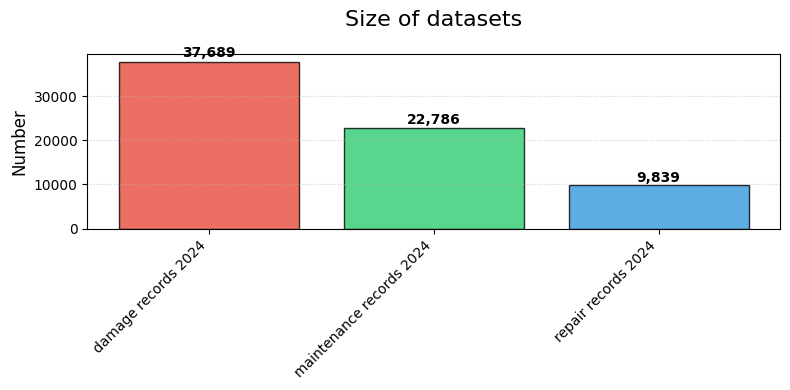

In [90]:
fig = plt.figure(figsize=(8, 4))
categories = ['damage records 2024', 'maintenance records 2024', 'repair records 2024']
values = [total_2024_damages, len(asset_maintenance_2024), len(asset_repair_2024)]
bars = plt.bar(categories, values, color=['#e74c3c', '#2ecc71', '#3498db'], edgecolor='black', alpha=0.8)

# Formatting
plt.title('Size of datasets', fontsize=16, pad=20)
plt.ylabel('Number', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Add data labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01),
             f'{int(height):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

number of unique maintenance IDs in damage records: 21999
number of unique maintenance IDs in maintenance records, 2024: 22786
number of unique maintenance IDs in maintenance records, 2025: 16029
number of unique maintenance IDs that appear in both 2024 and 2025 maintenance records: 0
number of unique maintenance IDs in 2024 maintenance records that also appear in damage records: 21655
number of unique maintenance IDs in 2025 maintenance records that also appear in damage records: 329
number of unique maintenance IDs in maintenance records (2024 & 2025) that also appear in damage records: 21984


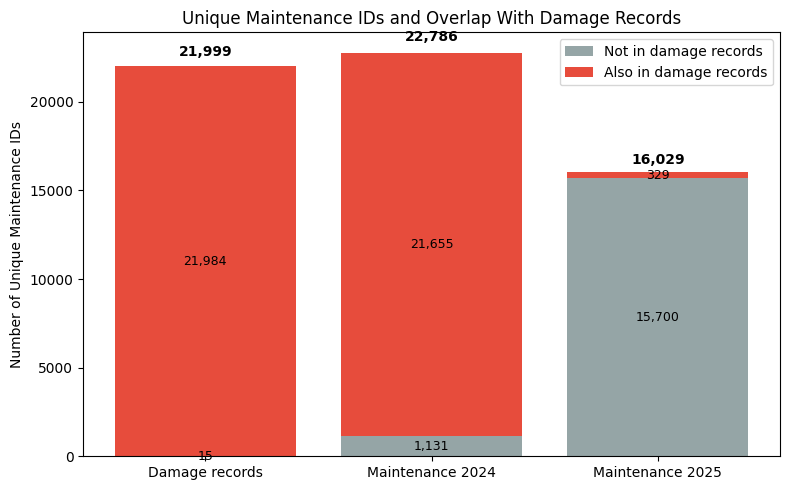

In [91]:
import matplotlib.pyplot as plt

total_2024_damages = len(asset_damage_2024)
unique_maintenance_id_damage = asset_damage_2024['asset_maintenance_id'].unique()
print(f'number of unique maintenance IDs in damage records: {len(unique_maintenance_id_damage)}')

unique_maintenance_id_maintenance_2024 = asset_maintenance_2024['asset_maintenance_id'].unique()
print(f'number of unique maintenance IDs in maintenance records, 2024: {len(unique_maintenance_id_maintenance_2024)}')
unique_maintenance_id_maintenance_2025 = asset_maintenance_2025['asset_maintenance_id'].unique()
print(f'number of unique maintenance IDs in maintenance records, 2025: {len(unique_maintenance_id_maintenance_2025)}')

both_2024_and_2025 = set(unique_maintenance_id_maintenance_2024) & set(unique_maintenance_id_maintenance_2025)
print(f'number of unique maintenance IDs that appear in both 2024 and 2025 maintenance records: {len(both_2024_and_2025)}')

total_overlapping_ids_damage_maintenance_2024 = set(unique_maintenance_id_maintenance_2024) & set(unique_maintenance_id_damage)
print(f'number of unique maintenance IDs in 2024 maintenance records that also appear in damage records: {len(total_overlapping_ids_damage_maintenance_2024)}')
total_overlapping_ids_damage_maintenance_2025 = set(unique_maintenance_id_maintenance_2025) & set(unique_maintenance_id_damage)
print(f'number of unique maintenance IDs in 2025 maintenance records that also appear in damage records: {len(total_overlapping_ids_damage_maintenance_2025)}')

total_unique_maintenance_id_maintenance = set(unique_maintenance_id_maintenance_2024) & set(unique_maintenance_id_damage) | set(unique_maintenance_id_maintenance_2025) & set(unique_maintenance_id_damage)

print(f'number of unique maintenance IDs in maintenance records (2024 & 2025) that also appear in damage records: {len(total_unique_maintenance_id_maintenance)}')

# Stacked bar chart showing overlap with damage records
labels = ['Damage records', 'Maintenance 2024', 'Maintenance 2025']
bar_1 = len(set(unique_maintenance_id_damage) - set(total_unique_maintenance_id_maintenance))
bar_1_overlap = len(total_unique_maintenance_id_maintenance)
bar_2 = len(unique_maintenance_id_maintenance_2024)
bar_2_overlap = len(total_overlapping_ids_damage_maintenance_2024)
bar_3 = len(unique_maintenance_id_maintenance_2025)
bar_3_overlap = len(total_overlapping_ids_damage_maintenance_2025)

bar_2_non_overlap = bar_2 - bar_2_overlap
bar_3_non_overlap = bar_3 - bar_3_overlap

non_overlap_values = [bar_1, bar_2_non_overlap, bar_3_non_overlap]
overlap_values = [bar_1_overlap, bar_2_overlap, bar_3_overlap]

x = range(len(labels))

plt.figure(figsize=(8, 5))
bar_base = plt.bar(x, non_overlap_values, label='Not in damage records', color='#95a5a6')
bar_overlap = plt.bar(x, overlap_values, bottom=non_overlap_values, label='Also in damage records', color='#e74c3c')

# Segment labels and totals on top
for idx in x:
    base = non_overlap_values[idx]
    overlap = overlap_values[idx]
    total = base + overlap
    if base > 0:
        plt.text(idx, base / 2, f'{base:,}', ha='center', va='center', fontsize=9)
    if overlap > 0:
        plt.text(idx, base + overlap / 2, f'{overlap:,}', ha='center', va='center', fontsize=9)
    plt.text(idx, total + max(total * 0.02, 1), f'{total:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(x, labels)
plt.ylabel('Number of Unique Maintenance IDs')
plt.title('Unique Maintenance IDs and Overlap With Damage Records')
plt.legend()
plt.tight_layout()
plt.show()



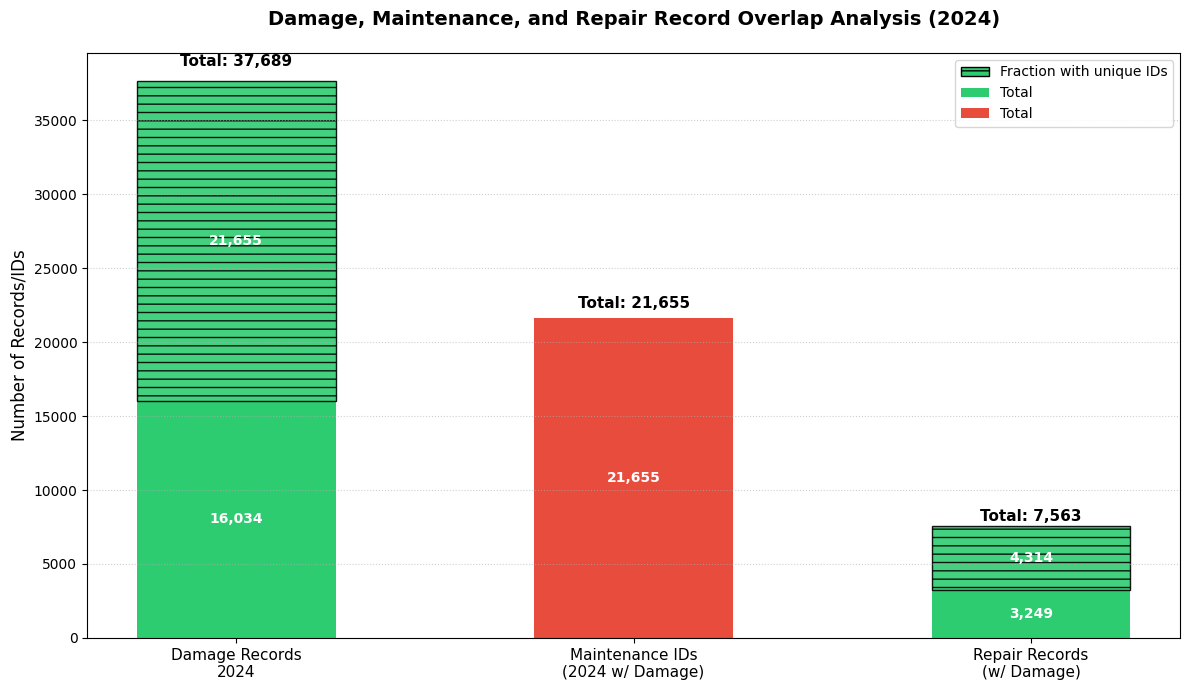

Of the 37,689 damage records in 2024, 21,655 (57.5%) have an associated maintenance record in 2024.
From these overlapping maintenance records, about 19.9% also have a repair record in 2024. These have an average of 1.8 repair records per maintenance ID, indicating that some maintenance cases involve multiple repairs.


In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate all required variables
total_2024_damages = len(asset_damage_2024)
unique_maintenance_id_damage = asset_damage_2024['asset_maintenance_id'].unique()
unique_maintenance_id_maintenance_2024 = asset_maintenance_2024['asset_maintenance_id'].unique()
unique_maintenance_id_maintenance_2025 = asset_maintenance_2025['asset_maintenance_id'].unique()

# Calculate overlaps
total_overlapping_ids_damage_maintenance_2024 = len(set(unique_maintenance_id_maintenance_2024) & set(unique_maintenance_id_damage))
total_overlapping_ids_damage_maintenance_2025 = len(set(unique_maintenance_id_maintenance_2025) & set(unique_maintenance_id_damage))

# Get repairs data
repairs_with_2024_damage = asset_repair_2024[asset_repair_2024['asset_maintenance_id'].isin(unique_maintenance_id_damage)]
unique_maintenance_id_repair_2024 = len(repairs_with_2024_damage['asset_maintenance_id'].unique())

# BAR 1: Damage records (2024) with shaded fraction for overlap with maintenance 2024
bar1_total = total_2024_damages
bar1_overlap = total_overlapping_ids_damage_maintenance_2024
bar1_non_overlap = bar1_total - bar1_overlap

# BAR 2: Total overlapping maintenance IDs (2024) with damage records
bar2_total = total_overlapping_ids_damage_maintenance_2024
bar2_overlap = bar2_total  # All are overlaps since it's the overlap set

# BAR 3: Repair records with damage overlap, shaded by unique maintenance IDs
bar3_total = len(repairs_with_2024_damage)
bar3_with_id = unique_maintenance_id_repair_2024
bar3_without_id = bar3_total - bar3_with_id

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))

labels = ['Damage Records\n2024', 'Maintenance IDs\n(2024 w/ Damage)', 'Repair Records\n(w/ Damage)']
x_pos = np.arange(len(labels))
width = 0.5

# Define styling
green_color = '#2ecc71'
hatch_style = '--'  # Dashed lines for the fraction
hatch_edge_color = 'black' # Color of the dashes

# Bar 1: Damage records - Green with dashed overlap
# Bottom part (No overlap)
ax.bar(x_pos[0], bar1_non_overlap, width, color=green_color, label='No overlap')
# Top part (Overlap fraction)
ax.bar(x_pos[0], bar1_overlap, width, bottom=bar1_non_overlap, 
       facecolor=green_color, hatch=hatch_style, edgecolor=hatch_edge_color, alpha=0.9,
       label='Overlap with Maintenance 2024')

# Bar 2: All overlapping maintenance IDs (Kept red for contrast)
ax.bar(x_pos[1], bar2_total, width, color='#e74c3c')

# Bar 3: Repair records - Green with dashed unique ID fraction
# Bottom part (Without ID)
ax.bar(x_pos[2], bar3_without_id, width, color=green_color)
# Top part (With ID fraction)
ax.bar(x_pos[2], bar3_with_id, width, bottom=bar3_without_id, 
       facecolor=green_color, hatch=hatch_style, edgecolor=hatch_edge_color, alpha=0.9)

# Add segment labels within bars
# Bar 1
if bar1_non_overlap > 0:
    ax.text(x_pos[0], bar1_non_overlap/2, f'{bar1_non_overlap:,}', 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
if bar1_overlap > 0:
    ax.text(x_pos[0], bar1_non_overlap + bar1_overlap/2, f'{bar1_overlap:,}', 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Bar 2
if bar2_total > 0:
    ax.text(x_pos[1], bar2_total/2, f'{bar2_total:,}', 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Bar 3
if bar3_without_id > 0:
    ax.text(x_pos[2], bar3_without_id/2, f'{bar3_without_id:,}', 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
if bar3_with_id > 0:
    ax.text(x_pos[2], bar3_without_id + bar3_with_id/2, f'{bar3_with_id:,}', 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Add total labels above each bar
totals = [bar1_total, bar2_total, bar3_total]
for i, total in enumerate(totals):
    ax.text(x_pos[i], total + max(total * 0.02, 5), f'Total: {total:,}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Number of Records/IDs', fontsize=12)
ax.set_title('Damage, Maintenance, and Repair Record Overlap Analysis (2024)', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=green_color, hatch=hatch_style, edgecolor=hatch_edge_color, label='Fraction with unique IDs'),
    Patch(facecolor=green_color, label='Total'),
    Patch(facecolor='#e74c3c', label='Total')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# ANALYSIS

print(f"Of the {total_2024_damages:,} damage records in 2024, {bar1_overlap:,} ({(bar1_overlap/bar1_total)*100:.1f}%) have an associated maintenance record in 2024.")
print(f"From these overlapping maintenance records, about {bar3_with_id/bar2_total*100:.1f}% also have a repair record in 2024. These have an average of {bar3_total/bar3_with_id:.1f} repair records per maintenance ID, indicating that some maintenance cases involve multiple repairs.")

In [93]:
# check how many fields where "set vehcile unavaliable" is true in the asset_damage_2024

vehicle_unavailable_count = asset_damage_2024['set_vehicle_unavailable'] == True
print(f"Number of records where 'set_vehicle_unavailable' is True: {vehicle_unavailable_count.sum():,}")

vehicle_unavailable_count = asset_damage_2024['set_vehicle_unavailable'] == False
print(f"Number of records where 'set_vehicle_unavailable' is False: {vehicle_unavailable_count.sum():,}")

# make a filtered dataset where set_vehicle_unavailable is false

filtered_asset_damage = asset_damage_2024[asset_damage_2024['set_vehicle_unavailable'] == False].copy()

filtered_asset_damage.head()

#print the different damage_type_names that we find under this dataset
print(filtered_asset_damage['damage_type_name'].unique())

#print the counts of the different damage_type_names
print(filtered_asset_damage['damage_type_name'].value_counts())


filtered_asset_damage.head()

#make a correlation matrix for the 


Number of records where 'set_vehicle_unavailable' is True: 32,727
Number of records where 'set_vehicle_unavailable' is False: 4,962
['Unauthorized Trip' 'Sete' 'Hjul' 'Gir' 'Lås' 'Ringeklokke' 'Console'
 'Setepinneklemme' 'Basket' 'Støtte' 'GPS' 'Skjerm(er)'
 'Brake(s) need adjustment' 'Styrelager' 'Cranck bearing/bottom bracket '
 'Frame']
damage_type_name
Gir                               1556
Unauthorized Trip                 1266
Sete                               798
Hjul                               485
Brake(s) need adjustment           188
GPS                                185
Setepinneklemme                    145
Ringeklokke                        107
Lås                                 81
Basket                              62
Støtte                              41
Skjerm(er)                          31
Console                             10
Styrelager                           3
Cranck bearing/bottom bracket        3
Frame                                1
Name: count, dty

,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,damage_id,created_at,comment,damage_type_id,damage_type_name,set_vehicle_unavailable,reported_by_administrator_id,reported_by_user_id,repeats,resolved_at,asset_maintenance_id
499566,29613,156,Urban Sharing Bike v1,bike,trondheim,1096335,2024-01-18 12:56:26.758000+00:00,NaN,338,Unauthorized Trip,False,NaN,NaN,1,2024-01-19 08:07:18.497000 +00:00,379459
504957,49,156,Urban Sharing Bike v1,bike,trondheim,1105833,2024-02-08 07:29:43.279000+00:00,NaN,338,Unauthorized Trip,False,NaN,NaN,1,2024-02-08 09:32:03.430000 +00:00,383702
512558,202,156,Urban Sharing Bike v1,bike,trondheim,1123284,2024-03-21 11:51:16.515000+00:00,NaN,338,Unauthorized Trip,False,NaN,NaN,1,2024-04-16 11:52:12.100000 +00:00,393594
512578,165,156,Urban Sharing Bike v1,bike,trondheim,1123339,2024-03-21 13:44:21.824000+00:00,NaN,338,Unauthorized Trip,False,NaN,NaN,2,2024-04-06 07:47:19.050000 +00:00,393624
512865,21,156,Urban Sharing Bike v1,bike,trondheim,1124220,2024-03-22 16:38:12.776000+00:00,NaN,338,Unauthorized Trip,False,NaN,NaN,1,2024-04-09 08:45:36.345000 +00:00,394118


In [94]:
import pandas as pd

# Create analysis by damage type
damage_type_analysis = asset_damage_2024.groupby('damage_type_name').agg(
    total_cases=('damage_id', 'count'),
    unavailable_cases=('set_vehicle_unavailable', lambda x: (x == True).sum())
).reset_index()

different_damage_types = damage_type_analysis['damage_type_name'].unique()
print(f"Number of different damage types: {len(different_damage_types)}")

# Calculate percentage
damage_type_analysis['percent_unavailable'] = (damage_type_analysis['unavailable_cases'] / damage_type_analysis['total_cases'] * 100).round(1)

# Rename columns for clarity
damage_type_analysis.columns = ['Damage Type', 'Total Cases', 'Cases Set Unavailable', '% Unavailable']

# Sort by percentage descending
damage_type_analysis = damage_type_analysis.sort_values('% Unavailable', ascending=False).reset_index(drop=True)

print("\n" + "="*90)
print("DAMAGE TYPE ANALYSIS: Percentage of Cases Resulting in Unavailable Bikes")
print("="*90)
print(damage_type_analysis.to_string(index=False))
print("="*90)


Number of different damage types: 27

DAMAGE TYPE ANALYSIS: Percentage of Cases Resulting in Unavailable Bikes
                   Damage Type  Total Cases  Cases Set Unavailable  % Unavailable
                       Battery           49                     49          100.0
                  Belte / Belt          199                    199          100.0
                     Bremse(r)          904                    904          100.0
                         Styre          706                    706          100.0
                     Vandalism            2                      2          100.0
       Unresponsive Controller        28489                  28489          100.0
        Too many quick returns         1222                   1222          100.0
                       Pedaler          344                    344          100.0
                           Lys           49                     49          100.0
                 Lock & unlock          113                    113   

In [95]:
# can you print information about the cases where the damage type is "gir" and set unavailable is true?

gir_unavailable_cases = asset_damage_2024[(asset_damage_2024['damage_type_name'] == 'Gir') & (asset_damage_2024['set_vehicle_unavailable'] == False)]
print(f"Number of cases with damage type 'Gir' and set_vehicle_unavailable = False: {len(gir_unavailable_cases)}")
print("\nSample of cases with damage type 'Gir' and set_vehicle_unavailable = False:")

display(gir_unavailable_cases.head(30))

Number of cases with damage type 'Gir' and set_vehicle_unavailable = False: 1556

Sample of cases with damage type 'Gir' and set_vehicle_unavailable = False:


,vehicle_id,asset_model_id,asset_model_name,vehicle_category,case,damage_id,created_at,comment,damage_type_id,damage_type_name,set_vehicle_unavailable,reported_by_administrator_id,reported_by_user_id,repeats,resolved_at,asset_maintenance_id
514337,4287,156,Urban Sharing Bike v1,bike,trondheim,1127341,2024-03-27 15:08:17.092000+00:00,NaN,741,Gir,False,NaN,12923.0,1,2025-02-18 09:59:31.362000 +00:00,394550
515003,132,156,Urban Sharing Bike v1,bike,trondheim,1129048,2024-03-30 15:37:16.765000+00:00,NaN,741,Gir,False,NaN,12923.0,1,2024-04-09 18:54:23.931000 +00:00,397315
515152,4234,156,Urban Sharing Bike v1,bike,trondheim,1129832,2024-04-01 18:30:02.699000+00:00,NaN,741,Gir,False,NaN,1293087.0,1,2024-05-13 06:45:10.156000 +00:00,397318
515459,263,156,Urban Sharing Bike v1,bike,trondheim,1130539,2024-04-02 18:00:45.801000+00:00,NaN,741,Gir,False,NaN,1289534.0,1,2024-04-14 13:22:09.699000 +00:00,398297
515665,4270,156,Urban Sharing Bike v1,bike,trondheim,1130962,2024-04-03 08:46:37.733000+00:00,NaN,741,Gir,False,NaN,786551.0,1,2024-04-06 08:00:57.921000 +00:00,398563
516061,62799,156,Urban Sharing Bike v1,bike,trondheim,1131901,2024-04-04 14:18:15.405000+00:00,NaN,741,Gir,False,NaN,914162.0,1,2024-06-07 10:05:13.385000 +00:00,399179
516368,4288,156,Urban Sharing Bike v1,bike,trondheim,1132537,2024-04-05 07:25:24.438000+00:00,NaN,741,Gir,False,NaN,917958.0,1,2024-07-03 12:15:00.382000 +00:00,399569
516419,4211,156,Urban Sharing Bike v1,bike,trondheim,1132728,2024-04-05 12:42:59.037000+00:00,NaN,741,Gir,False,NaN,781457.0,1,2024-04-18 13:36:39.533000 +00:00,399701
516428,263,156,Urban Sharing Bike v1,bike,trondheim,1132784,2024-04-05 13:59:04.712000+00:00,NaN,741,Gir,False,NaN,1069968.0,1,2024-04-14 13:22:09.699000 +00:00,398297
516502,4234,156,Urban Sharing Bike v1,bike,trondheim,1133076,2024-04-05 19:09:50.162000+00:00,NaN,741,Gir,False,NaN,810717.0,1,2024-05-13 06:45:10.156000 +00:00,397318


C:\Users\ingvivsu\AppData\Local\Temp\ipykernel_3812\3644882304.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  asset_damage_2024['month'] = asset_damage_2024['created_at'].dt.to_period('M')
C:\Users\ingvivsu\AppData\Local\Temp\ipykernel_3812\3644882304.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  asset_maintenance_2024['month'] = asset_maintenance_2024['started_at'].dt.to_period('M')
C:\Users\ingvivsu\AppData\Local\Temp\ipykernel_3812\3644882304.py:27: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  asset_repair_2024['month'] = asset_repair_2024['created_at'].dt.to_period('M')


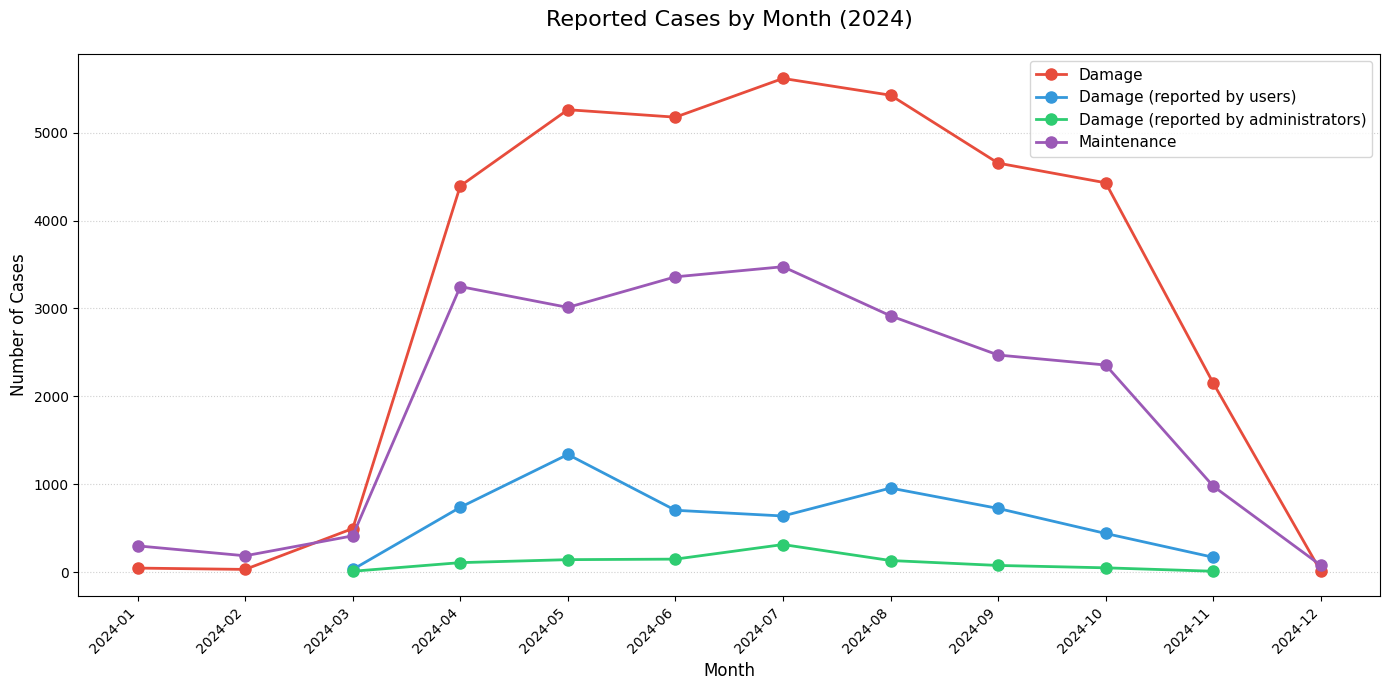


Monthly Case Summary:

Damage:
  Total cases: 37,689
  Average per month: 3140.8
  Peak month: 2024-07 (5618 cases)

Damage (reported by users):
  Total cases: 5,732
  Average per month: 636.9
  Peak month: 2024-05 (1338 cases)

Damage (reported by administrators):
  Total cases: 980
  Average per month: 108.9
  Peak month: 2024-07 (313 cases)

Maintenance:
  Total cases: 22,786
  Average per month: 1898.8
  Peak month: 2024-07 (3475 cases)

Repair:
  Total cases: 9,839
  Average per month: 819.9
  Peak month: 2024-06 (1571 cases)


In [96]:
# Plot number of reported cases by month for each dataset
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for each dataset
monthly_data = {}

# Asset damage - count by month using 'created_at'
if 'asset_damage_2024' in globals():
    asset_damage_2024['month'] = asset_damage_2024['created_at'].dt.to_period('M')
    monthly_data['Damage'] = asset_damage_2024.groupby('month').size()

    #plot number of cases that are reported by users ( where the field reported_by_user_id is not null) by month using 'created_at'
    asset_damage_2024['reported_by_user'] = asset_damage_2024['reported_by_user_id'].notna()
    monthly_data['Damage (reported by users)'] = asset_damage_2024[asset_damage_2024['reported_by_user']].groupby('month').size()

    asset_damage_2024['reported_by_administrator_id'] = asset_damage_2024['reported_by_administrator_id'].notna()
    monthly_data['Damage (reported by administrators)'] = asset_damage_2024[asset_damage_2024['reported_by_administrator_id']].groupby('month').size()

# Asset maintenance - count by month using 'started_at'
if 'asset_maintenance_2024' in globals():
    asset_maintenance_2024['month'] = asset_maintenance_2024['started_at'].dt.to_period('M')
    monthly_data['Maintenance'] = asset_maintenance_2024.groupby('month').size()

# Asset repair - count by month using 'created_at'
if 'asset_repair_2024' in globals():
    asset_repair_2024['month'] = asset_repair_2024['created_at'].dt.to_period('M')
    monthly_data['Repair'] = asset_repair_2024.groupby('month').size()

# Create the plot
plt.figure(figsize=(14, 7))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
for (label, counts), color in zip(monthly_data.items(), colors):
    months = counts.index.astype(str)
    plt.plot(months, counts.values, marker='o', linewidth=2, label=label, color=color, markersize=8)

plt.title('Reported Cases by Month (2024)', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary
print("\nMonthly Case Summary:")
for label, counts in monthly_data.items():
    print(f"\n{label}:")
    print(f"  Total cases: {counts.sum():,}")
    print(f"  Average per month: {counts.mean():.1f}")
    print(f"  Peak month: {counts.idxmax()} ({counts.max()} cases)")

# Trip and maintenance data linking

In [97]:
# Explore potential linking fields between trip data and maintenance data
print("=" * 80)
print("INVESTIGATING POTENTIAL DATA LINKS")
print("=" * 80)

# 1. Check columns in each dataset
print("\n📋 TRIP DATA COLUMNS:")
print(f"   {list(trip_data_2024.columns)}")

print("\n📋 ASSET_DAMAGE_2024 COLUMNS:")
print(f"   {list(asset_damage_2024.columns)}")

print("\n📋 ASSET_MAINTENANCE_2024 COLUMNS:")
print(f"   {list(asset_maintenance_2024.columns)}")

print("\n📋 ASSET_REPAIR_2024 COLUMNS:")
print(f"   {list(asset_repair_2024.columns)}")

# Print list of common columns 

common_columns = set(asset_damage_2024.columns) & set(asset_maintenance_2024.columns) & set(asset_repair_2024.columns)

print("\nCOMMON COLUMNS ACROSS ALL DAMAGE RELATED DATASETS:")
print(common_columns)

# 2. Check for vehicle/asset ID overlap
print("\n" + "=" * 80)
print("POTENTIAL LINKING STRATEGIES:")
print("=" * 80)

# Check unique vehicle IDs in trip data
trip_vehicles = trip_data_2024['vehicle_id'].unique()
print(f"\n🚲 Trip data: {len(trip_vehicles):,} unique vehicles")
print(f"   Sample IDs: {list(trip_vehicles[:5])}")

# Check unique vehcile IDs in damage data
damaged_vehicles = asset_damage_2024['vehicle_id'].unique()
print(f"\n🔧 Damage data: {len(damaged_vehicles):,} unique vehicles")


maintenance_vehicles = asset_maintenance_2024['vehicle_id'].unique()
print(f"\n🛠️ Maintenance data: {len(maintenance_vehicles):,} unique vehicles")

repair_vehicles = asset_repair_2024['vehicle_id'].unique()
print(f"\n🔩 Repair data: {len(repair_vehicles):,} unique vehicles")


INVESTIGATING POTENTIAL DATA LINKS

📋 TRIP DATA COLUMNS:
   ['vehicle_id', 'position_at', 'position_wkt', 'position_latitude', 'position_longitude', 'position_accuracy', 'trip_started_at', 'trip_ended_at', 'trip_id', 'trip_state', 'trip_unlock_method', 'trip_start_dock_number', 'trip_start_dock_group_id', 'trip_start_dock_group_title', 'trip_end_dock_number', 'trip_end_dock_group_id', 'trip_end_dock_group_title', 'user_id', 'product_id', 'product_name', 'product_price', 'product_sales_channel', 'product_sales_locale', 'sale_from_value_code']

📋 ASSET_DAMAGE_2024 COLUMNS:
   ['vehicle_id', 'asset_model_id', 'asset_model_name', 'vehicle_category', 'case', 'damage_id', 'created_at', 'comment', 'damage_type_id', 'damage_type_name', 'set_vehicle_unavailable', 'reported_by_administrator_id', 'reported_by_user_id', 'repeats', 'resolved_at', 'asset_maintenance_id', 'month', 'reported_by_user']

📋 ASSET_MAINTENANCE_2024 COLUMNS:
   ['vehicle_id', 'asset_model_id', 'asset_model_name', 'vehicle_c

In [98]:
# check for overlap between trip vehicles and damaged vehicles
overlap_damage = set(trip_vehicles) & set(damaged_vehicles)
print(f"\n🔗 Overlap between trip vehicles and damaged vehicles: {len(overlap_damage):,} vehicles")

overlap_maintenance = set(trip_vehicles) & set(maintenance_vehicles)
print(f"\n🔗 Overlap between trip vehicles and maintenance vehicles: {len(overlap_maintenance):,} vehicles")

overlap_repair = set(trip_vehicles) & set(repair_vehicles)
print(f"\n🔗 Overlap between trip vehicles and repair vehicles: {len(overlap_repair):,} vehicles")


🔗 Overlap between trip vehicles and damaged vehicles: 675 vehicles

🔗 Overlap between trip vehicles and maintenance vehicles: 675 vehicles

🔗 Overlap between trip vehicles and repair vehicles: 673 vehicles


In [99]:
# print the different values under the vehcile category column in the damage data
print(f"\n🔍 Vehicle categories in damage data:")
print(asset_damage_2024['vehicle_category'].unique())

# print uniqe categories of asset_model_id,asset_model_name
print(asset_damage_2024['asset_model_id'].unique())
print(asset_damage_2024['asset_model_name'].unique())


🔍 Vehicle categories in damage data:
['bike']
[156]
['Urban Sharing Bike v1']


In [100]:
# check trip data

overlap = set(overlap_damage) & set(overlap_maintenance) & set(overlap_repair)

non_overlap_damage = set(damaged_vehicles) - set(trip_vehicles)
non_overlap_maintenance = set(maintenance_vehicles) - set(trip_vehicles)
non_overlap_repair = set(repair_vehicles) - set(trip_vehicles)


print(len(overlap))
print(len(non_overlap_damage))
print(len(non_overlap_maintenance))
print(len(non_overlap_repair))

non_overlap_damage_maintenance = set(non_overlap_damage) - set(non_overlap_maintenance)
print(len(non_overlap_damage_maintenance))
non_overlap_damage_repair = set(non_overlap_damage) - set(non_overlap_repair)
print(len(non_overlap_damage_repair))
non_overlap_maintenance_repair = set(non_overlap_maintenance) - set(non_overlap_repair)
print(len(non_overlap_maintenance_repair))

673
90
89
88
1
2
1


In [101]:
# from damage, maintenance and repair data, filter out all records that have a vehicle_id that is not in the trip data, and then print the number of records that are left in each dataset after this filtering.

filtered_damage = asset_damage_2024[asset_damage_2024['vehicle_id'].isin(trip_vehicles)]
print(f"\nAfter filtering damage data for vehicles in trip data: {len(filtered_damage):,} records remain")

filtered_maintenance = asset_maintenance_2024[asset_maintenance_2024['vehicle_id'].isin(trip_vehicles)]
print(f"\nAfter filtering maintenance data for vehicles in trip data: {len(filtered_maintenance):,} records remain")

filtered_repair = asset_repair_2024[asset_repair_2024['vehicle_id'].isin(trip_vehicles)]
print(f"\nAfter filtering repair data for vehicles in trip data: {len(filtered_repair):,} records remain")




After filtering damage data for vehicles in trip data: 33,796 records remain

After filtering maintenance data for vehicles in trip data: 20,304 records remain

After filtering repair data for vehicles in trip data: 8,426 records remain


# Specific vehcile movement analysis


**Analysis Overview:**  
We checked the relationship between damage reports and recorded trips to validate data consistency.

**Key Findings:**

**(1) Cases where `set_vehicle_unavailable = True` (106,000+ cases):**
- Only **203 trips** were recorded during periods when bikes should have been unavailable
- Spot checks revealed that many vehicles have multiple damage reports where some are marked `True` and others `False` for `set_unavailable` simultaneously
- This explains why trips still occur—the bike may have concurrent damage cases with different availability statuses

**(2) Cases where `set_vehicle_unavailable = False` (4,940 cases):**
- Over **100,000 trips** were recorded during these damage windows
- This makes sense: bikes with minor/non-blocking damage can still be ridden

**Conclusion:**  
There is a **clear and consistent link** between the trip and damage datasets. The patterns confirm that the system data behaves as expected—bikes unavailable due to critical damage show minimal trip activity, while bikes with non-blocking damage continue normal operation.

In [102]:
# Trips that start within the damage window (created_at -> resolved_at) for cases that set vehicle unavailable
import pandas as pd
from tabulate import tabulate

# Choose the per-trip table if it exists, otherwise fall back to the raw trip data
trips_df = trip_data.copy()

# Keep relevant columns and ensure datetimes (force UTC to avoid tz-aware vs tz-naive comparisons)
trips_df = trips_df[['trip_id', 'vehicle_id', 'trip_started_at', 'trip_ended_at']].copy()
trips_df['trip_started_at'] = pd.to_datetime(trips_df['trip_started_at'], errors='coerce', utc=True)
trips_df['trip_ended_at'] = pd.to_datetime(trips_df['trip_ended_at'], errors='coerce', utc=True)

# If trip_ended_at is missing, delete row
trips_df = trips_df[trips_df['trip_ended_at'].notna()].copy()

# Damage window data (only cases that set vehicle unavailable)
damage_df = asset_damage_2024.copy()
damage_df['created_at'] = pd.to_datetime(damage_df['created_at'], errors='coerce', utc=True)
damage_df['resolved_at'] = pd.to_datetime(damage_df['resolved_at'], errors='coerce', utc=True)

# Keep only rows with a valid window and flagged unavailable
damage_df = damage_df[
    damage_df['created_at'].notna()
    & damage_df['resolved_at'].notna()
    & (damage_df['set_vehicle_unavailable'] == True)
].copy()

damage_df = damage_df[[
    'damage_id',
    'asset_maintenance_id',
    'vehicle_id',
    'damage_type_name',
    'set_vehicle_unavailable',
    'created_at',
    'resolved_at'
]].copy()

# Join trips with damage windows by vehicle_id
merged = trips_df.merge(damage_df, on='vehicle_id', how='inner')

# A trip is within the window if it starts between created_at and resolved_at for that damage_id
within_window_mask = (merged['trip_started_at'] >= merged['created_at']) & (merged['trip_started_at'] <= merged['resolved_at'])
window_trips = merged[within_window_mask].copy()

print(f"Trips considered: {len(trips_df):,}")
print(f"Damage windows (unavailable=True): {len(damage_df):,}")
print(f"Trips starting within window rows: {len(window_trips):,}")

# Summary per damage case (the main unit of analysis)
damage_summary = (
    window_trips.groupby('damage_id')
    .agg(
        vehicle_id=('vehicle_id', 'first'),
        asset_maintenance_id=('asset_maintenance_id', 'first'),
        damage_type_name=('damage_type_name', 'first'),
        created_at=('created_at', 'first'),
        resolved_at=('resolved_at', 'first'),
        trips_in_window=('trip_id', 'nunique')
    )
    .sort_values('trips_in_window', ascending=False)
    .reset_index()
 )

print("\nDamage cases with trips during the window:")
print(tabulate(damage_summary.head(20), headers='keys', tablefmt='psql', showindex=False))

# Summary per vehicle (how many unavailable damage cases had trips)
vehicle_summary = (
    window_trips.groupby('vehicle_id')
    .agg(
        trips_in_window=('trip_id', 'nunique'),
        damage_cases_with_trips=('damage_id', 'nunique')
    )
    .sort_values(['damage_cases_with_trips', 'trips_in_window'], ascending=False)
    .reset_index()
 )

print("\nVehicles with trips during unavailable damage windows:")
print(tabulate(vehicle_summary.head(20), headers='keys', tablefmt='psql', showindex=False))

# Damage cases with no trips in their window
damage_ids_with_trips = set(damage_summary['damage_id'])
damage_ids_all = set(damage_df['damage_id'])
damage_ids_without_trips = sorted(damage_ids_all - damage_ids_with_trips)

print(f"\nUnavailable damage cases with no trips in window: {len(damage_ids_without_trips):,}")
print("Sample:", damage_ids_without_trips[:20])

Trips considered: 151,278
Damage windows (unavailable=True): 32,727
Trips starting within window rows: 203

Damage cases with trips during the window:
+-------------+--------------+------------------------+------------------------+----------------------------------+----------------------------------+-------------------+
|   damage_id |   vehicle_id |   asset_maintenance_id | damage_type_name       | created_at                       | resolved_at                      |   trips_in_window |
|-------------+--------------+------------------------+------------------------+----------------------------------+----------------------------------+-------------------|
|     1196983 |          388 |                 434124 | Styre                  | 2024-05-28 10:14:22.196000+00:00 | 2024-06-13 11:43:13.182000+00:00 |                64 |
|     1164672 |        62454 |                 418110 | Lock & unlock          | 2024-05-06 07:08:04.186000+00:00 | 2024-08-08 11:46:18.846000+00:00 |               